In [75]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [95]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

memory = SqliteSaver.from_conn_string(":memory:")

In [96]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

In [97]:
PLAN_PROMPT = """You are an expert report writer tasked with writing a high level outline of an report. \
Write such an outline for the user provided topic. Give an outline of the report along with any relevant notes \
or instructions for the sections."""

RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following report. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""

WRITER_PROMPT = """You are an report assistant tasked with writing excellent a one page report.\
Generate the best report possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

REFLECTION_PROMPT = """You are a teacher grading an report submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [98]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [99]:
from langchain_core.pydantic_v1 import BaseModel

class Queries(BaseModel):
    queries: List[str]


In [100]:
from tavily import TavilyClient
import os 
tavily = TavilyClient()

In [101]:
def planNode(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]
    response= llm.invoke(messages)
    return {"plan": response.content}

In [102]:
def researchNode(state: AgentState):
    queries = llm.with_structured_output(Queries)
    queries.invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    
    content = state.get('content', [])

    for q in queries.queries:
        response = tavily.search(query=q, max_results=3)
        for r in response['results']:
            content.append(r['content'])
        
    return {"content": content}


In [103]:
def generationNode(state: AgentState):
    content="\n\n".join(state['content'] or [])
    
    user_message = HumanMessage(content=f"{state['task']} \n\n Here is my plan {state['plan']}")
    
    message = [
        SystemMessage(content=WRITER_PROMPT.format(content=content)),
        user_message
    ]
    
    response = llm.invoke(message)
    
    return {
        "draft": response.content,
        "revision_number": state.get("revision_number", 1) + 1
    }

In [104]:
def reflectionNode(state: AgentState):
    messages= [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state["draft"])
    ]
    
    response = llm.invoke(messages)
    
    return {"critique": response.content}

In [105]:
def researchCritiqueNode(state: AgentState):
    queries = llm.with_structured_output(Queries.invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ]))
    
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response.get('results', []):
            content.append(r['content'])
            
    return {"content": content}    

In [106]:
def toContinue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    
    return "reflect"

In [107]:
bulider = StateGraph(AgentState)

bulider.add_node("planner", planNode)
bulider.add_node("research_plan", researchNode)
bulider.add_node("generate", generationNode)
bulider.add_node("reflect", reflectionNode)
bulider.add_node("research_critique", researchCritiqueNode)

In [108]:
bulider.add_conditional_edges(
    "generate",
    toContinue,
    {END: END, "reflect": "reflect"}
)

In [109]:
bulider.set_entry_point("planner")
bulider.add_edge("planner", "research_plan")
bulider.add_edge("research_plan", "generate")
bulider.add_edge("reflect", "research_critique")
bulider.add_edge("research_critique", "generate")

In [110]:
from langgraph.checkpoint.memory import MemorySaver

graph = bulider.compile(checkpointer=MemorySaver())

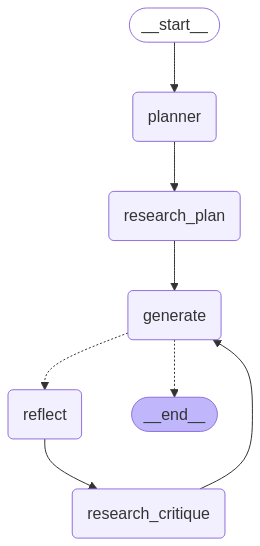

In [111]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [93]:
import pprint

thread = {"configurable": {"thread_id": "001"}}

for s in graph.stream(
    {"task": "AI Boon or Bane", "max_revisions": 2, "revision_number": 1}, 
    thread
):
    pprint.pprint(s)


{'planner': {'plan': '**Report Title:** AI Boon or Bane: Exploring the Impact '
                     'of Artificial Intelligence on Society\n'
                     '\n'
                     '**I. Executive Summary (approx. 100-150 words)**\n'
                     "* Brief overview of the report's main points\n"
                     '* Introduction to the topic of AI and its growing '
                     'presence in society\n'
                     '* Thesis statement: AI has the potential to be both a '
                     'boon and a bane, depending on how it is developed and '
                     'utilized.\n'
                     '\n'
                     '**II. Introduction (approx. 200-250 words)**\n'
                     '* Definition of Artificial Intelligence (AI) and its '
                     'history\n'
                     '* Current state of AI development and its applications\n'
                     '* Importance of evaluating the impact of AI on society\n'
           

AttributeError: type object 'Queries' has no attribute 'invoke'